In [3]:
from typing import List, Dict
from uuid import UUID

from sqlalchemy.orm import Session as OrmSession

from app.models.database import Message  # مسیر واقعی مدل خودتون رو بذارید


def get_last_messages(
    db: OrmSession,
    session_id: UUID,
    limit: int = 10,
) -> List[Dict[str, str]]:
    """
    آخرین `limit` پیام مربوط به یک session را برمی‌گرداند
    (به ترتیب زمانی صعودی، یعنی قدیمی‌ترین اول).
    """
    messages = (
        db.query(Message)
        .filter(Message.session_id == session_id)
        .order_by(Message.created_at.desc(), Message.id.desc())
        .limit(limit)
        .all()
    )

    # چون با desc گرفتیم، باید معکوس کنیم تا ترتیب زمانی درست بشه
    messages.reverse()

    return [
        {"role": msg.role, "content": msg.content}
        for msg in messages
    ]

In [4]:
from app.core.database.database import AppSessionLocal

session_id = "f5293d1f-139c-46db-97cc-1d0b95b222ff"

db = AppSessionLocal()

try:
    messages = get_last_messages(db, session_id, limit=10)
    print(messages)
finally:
    db.close()

[{'role': 'user', 'content': 'سیستم rag در چه سالی و توسط چه کسی اورده شد ؟'}, {'role': 'assistant', 'content': 'بر اساس مقدمه و پیشینه ارائه شده در Context [1]، معماری RAG نخستین بار توسط لوئیس و همکارانش در سال ۲۰۲۰ معرفی شده است.'}, {'role': 'user', 'content': 'درباره معماری های rag توضیح بده'}, {'role': 'agent', 'content': 'بر اساس مستندات ارائه شده، معماری\u200cهای پیشرفته سیستم\u200cهای RAG شامل چند رویکرد مهم هستند:\n\n1. **HyDE (Hypothetical Document Embeddings)**: در این روش ابتدا یک سند فرضی بر اساس پرسش کاربر تولید می\u200cشود و سپس از این سند برای جستجو در پایگاه داده استفاده می\u200cگردد. این کار باعث بهبود کیفیت بازیابی می\u200cشود، به\u200cویژه زمانی که پرسش اولیه اطلاعات کافی برای جستجوی دقیق ندارد. علاوه بر HyDE، تکنیک\u200cهای پیشرفته دیگری نیز به کار می\u200cروند مانند بازنویسی پرسش (Query Rewriting) برای افزایش دقت بازیابی، بازیابی چندمرحله\u200cای (Multi-hop Retrieval) برای پاسخ به پرسش\u200cهای پیچیده و ادغام نتایج چند مدل یا منبع بازیابی (Fusion of Retrieval Resu

In [15]:
def _format_history(history: List[Dict[str, str]]) -> str:
    if not history:
        return "(تاریخچه‌ای موجود نیست)"

    lines = []
    for m in history:
        role = "کاربر" if m["role"] == "user" else "دستیار"
        lines.append(f"{role}: {m['content']}")

    return "\n\n".join(lines)

In [16]:
import markdown
from IPython.display import display, HTML

def print_md(content):
    content = markdown.markdown(content)
    content = "<div dir=rtl>{}</div>".format(content)
    display(HTML(content))

a = _format_history(messages)
print_md(a)

In [ ]:
messages

[{'role': 'user', 'content': 'سیستم rag در چه سالی و توسط چه کسی اورده شد ؟'},
 {'role': 'assistant',
  'content': 'بر اساس مقدمه و پیشینه ارائه شده در Context [1]، معماری RAG نخستین بار توسط لوئیس و همکارانش در سال ۲۰۲۰ معرفی شده است.'},
 {'role': 'user', 'content': 'درباره معماری های rag توضیح بده'},
 {'role': 'agent',
  'content': 'بر اساس مستندات ارائه شده، معماری\u200cهای پیشرفته سیستم\u200cهای RAG شامل چند رویکرد مهم هستند:\n\n1. **HyDE (Hypothetical Document Embeddings)**: در این روش ابتدا یک سند فرضی بر اساس پرسش کاربر تولید می\u200cشود و سپس از این سند برای جستجو در پایگاه داده استفاده می\u200cگردد. این کار باعث بهبود کیفیت بازیابی می\u200cشود، به\u200cویژه زمانی که پرسش اولیه اطلاعات کافی برای جستجوی دقیق ندارد. علاوه بر HyDE، تکنیک\u200cهای پیشرفته دیگری نیز به کار می\u200cروند مانند بازنویسی پرسش (Query Rewriting) برای افزایش دقت بازیابی، بازیابی چندمرحله\u200cای (Multi-hop Retrieval) برای پاسخ به پرسش\u200cهای پیچیده و ادغام نتایج چند مدل یا منبع بازیابی (Fusion of Retriev

In [20]:
from enum import Enum
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

from app.core import settings


class RouteDecision(str, Enum):
    history = "history"
    retrieve = "retrieve"
    both = "both"
    none = "none"


class RouterOutput(BaseModel):
    decision: RouteDecision = Field(
        description="دسته‌بندی نهایی پرسش کاربر"
    )


llm = ChatOpenAI(
    model="gpt-4.1-mini",
    temperature=0,
    max_tokens=256,
    base_url="https://api.gapgpt.app/v1",
    api_key=settings.OPENAI_API_KEY,
)

structured_llm = llm.with_structured_output(RouterOutput)


SYSTEM_PROMPT = """تو یک روتر (Router) هستی که وظیفه‌ات تشخیص نوع نیاز اطلاعاتی پرسش کاربر است.
موضوع مستندات و دانش این سیستم: "سیستم‌های RAG (Retrieval-Augmented Generation)" است.

باید دقیقاً یکی از این ۴ مقدار را برای هر پرسش انتخاب کنی:

1. history:
   پرسش کاربر درباره‌ی مکالمه یا پیام‌های قبلی خودشان است (مثلاً: "چی گفتم؟"،
   "سوال قبلی من چی بود؟"، "خلاصه‌ی صحبت‌های ما تا الان چیه؟").
   هیچ نیازی به جستجو در مستندات (vector search) نیست.

2. retrieve:
   پرسش کاربر کاملاً یک سوال جدید و مستقل درباره‌ی موضوع مستندات (RAG) است
   و هیچ ارتباطی به تاریخچه‌ی مکالمه ندارد. برای پاسخ به آن حتماً باید
   در پایگاه دانش (vector search) جستجو شود.

3. both:
   پرسش کاربر هم به تاریخچه‌ی مکالمه وابسته است (مثلاً ادامه‌ی بحث قبلی،
   ارجاع با "اون"، "همینی که گفتی"، ضمایر ارجاعی) و هم برای پاسخ کامل
   نیاز به جستجوی اطلاعات جدید در مستندات دارد.

4. none:
   پرسش کاربر کاملاً بی‌ربط به موضوع مستندات (سیستم‌های RAG) است و به
   تاریخچه هم مربوط نیست (مثلاً: "هوا امروز چطوره؟"، "یک شعر بگو").

فقط و فقط یکی از این ۴ مقدار را برگردان: history, retrieve, both, none
هیچ توضیح اضافه‌ای نده.
"""

router_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", SYSTEM_PROMPT),
        ("human", "{query}"),
    ]
)

router_chain = router_prompt | structured_llm


def route_query(query: str) -> RouteDecision:
    result: RouterOutput = router_chain.invoke({"query": query})
    return result.decision

In [21]:
decision = route_query("سوال قبلیم رو خوب پاسخ نگرفتم اون رو بهتر توضیح بده و راحت تر و همچنین درباره کاربرد ان در هوش تجاری بگو")
print(decision)  # RouteDecision.history

# decision = route_query("تفاوت RAG با fine-tuning چیه؟")
# print(decision)  # RouteDecision.retrieve

# decision = route_query("همون روشی که گفتی رو با یه مثال کامل‌تر توضیح بده")
# print(decision)  # RouteDecision.both

# decision = route_query("امروز هوا چطوره؟")
# print(decision)  # RouteDecision.none

RouteDecision.both


/home/son/Desktop/rag/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 7397.43it/s]


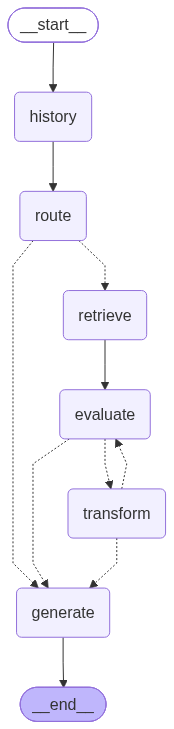

In [1]:
from app.agent.graph import graph

from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))

In [1]:
from app.agent.agent import run_agent

TEST_SESSION_ID = "f5293d1f-139c-46db-97cc-1d0b95b222ff"

# test_cases = [
#     ("تفاوت RAG با fine-tuning چیه؟", "→ باید بره retrieve"),
#     ("سوال قبلی من چی بود؟", "→ باید بره history"),
#     ("همون روشی که گفتی رو با جزئیات بیشتر توضیح بده", "→ باید بره both"),
#     ("امروز هوا چطوره؟", "→ باید بره none"),
# ]

# for query, expectation in test_cases:
#     print("=" * 60)
#     print(f"سوال: {query}")
#     print(f"انتظار: {expectation}")
#     result = run_agent(query, session_id=TEST_SESSION_ID)
#     print(f"route تشخیص‌داده‌شده: {result.get('route')}")
#     print(f"context (طول): {len(result.get('context') or '')}")
#     print(f"history (تعداد پیام): {len(result.get('history') or [])}")
#     print(f"answer: {result.get('answer')}")

/home/son/Desktop/rag/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Fetching 18 files: 100%|██████████| 18/18 [00:02<00:00,  8.08it/s]


In [1]:
messages

NameError: name 'messages' is not defined

In [2]:
query = "سکشن سوم مستند درباره چیه ؟"

In [3]:
result = run_agent(query, session_id=TEST_SESSION_ID)


TypeError: run_agent() missing 1 required positional argument: 'db'

In [13]:
result

{'query': 'سوال قبلیم درباره چی بود و همچنین درباره کاربرد سیستم های رگ در هوش تجاری بگو',
 'session_id': 'f5293d1f-139c-46db-97cc-1d0b95b222ff',
 'route': 'both',
 'parent_ids': ['1', '7'],
 'child_ids': [],
 'context': '### [1] مقدمه و پیشینه\n\nدر دنیای امروز، مدل های زبانی بزرگ (LLM) به یکی از پایه های اصلی نرم افزارهای هوشمند تبدیل\nشده اند. این مدل ها قادرند متون طبیعی را درک کرده، آن ها را تحلیل کنند و پاسخ هایی دقیق و روان\nتولید نمایند. با این حال، یکی از بزرگ ترین چالش های این مدل ها آن است که دانش آن ها به زمان\nآموزش محدود می شود و دسترسی مستقیمی به داده های جدید، اختصاصی یا سازمانی ندارند.\nبرای رفع این محدودیت، رویکرد «بازیابی-  افزوده تولید» یاRAG (Retrieval-Augmented\nGeneration)   مطرح شد. این رویکرد ترکیبی از دو مرحله اصلی است:\n1.   در مرحله اول، اطالعات مرتبط از یک پایگاه دانش بیرونی بازیابی می شود.\n2.   در مرحله دوم، مدل زبانی از این اطالعات بازیابی شده به عنوان زمینه (Context) استفاده می کند\nتا پاسخ نهایی را تولید نماید.\nمعماری RAG   نخستین بار توسط لوئیس و همک

In [2]:
import markdown
from IPython.display import display, HTML

def print_md(content):
    content = markdown.markdown(content)
    content = "<div dir=rtl>{}</div>".format(content)
    display(HTML(content))

# print_md(result['answer'])

In [19]:
s1 = "حامد جان، درباره کاربرد دقیق سیستم‌های RAG در هوش تجاری (BI) بر اساس بخش [7] مستندات، می‌توان این موارد را اشاره کرد:\n\n- تحلیل خودکار گزارش‌های سازمانی: RAG می‌تواند گزارش‌های پیچیده و حجیم را به صورت خودکار تحلیل کند و نکات مهم را استخراج نماید.\n- پاسخ‌گویی به پرسش‌های مدیریتی: مدیران با طرح سوالات خاص می‌توانند پاسخ‌های دقیق و مرتبط بر اساس داده‌های داخلی سازمان دریافت کنند.\n- تولید داشبوردهای هوشمند: RAG قادر است داشبوردهایی با توضیحات متنی هوشمند تولید کند که فهم داده‌ها را برای کاربران آسان‌تر می‌کند.\n- استخراج بینش (Insight): این سیستم‌ها می‌توانند از داده‌های ساخت‌یافته و غیرساخت‌یافته، بینش‌های ارزشمندی استخراج کنند که به تصمیم‌گیری بهتر کمک می‌کند.\n\nاین قابلیت‌ها باعث شده‌اند RAG به ابزاری کلیدی در سیستم‌های هوش تجاری مدرن تبدیل شود و فرآیند تحلیل داده و تصمیم‌گیری را به شکل قابل توجهی بهبود بخشد. اگر بخواهی، می‌توانم درباره هر کدام از این کاربردها جزئیات بیشتری هم ارائه دهم."
print_md(s1)

In [16]:
s

SyntaxError: unterminated string literal (detected at line 1) (4038558972.py, line 1)

In [8]:
print_md(s)

In [18]:
s1 = "سلام، منظور من این بود که من به عنوان دستیار تخصصی در زمینه سیستم‌های RAG (Retrieval-Augmented Generation) طراحی شده‌ام و می‌توانم در این حوزه به شما کمک کنم. اگر سوالی درباره سیستم‌های RAG دارید، خوشحال می‌شوم پاسخ دهم. اگر منظورتان چیز دیگری است، لطفاً دقیق‌تر بفرمایید تا بهتر راهنمایی کنم."


In [19]:
print_md(s1)

In [24]:
s2 = "پایگاه داده برداری (Vector Store) یکی از اجزای کلیدی سیستم‌های RAG است که برای ذخیره و جستجوی بردارهای عددی چندبعدی استفاده می‌شود. در این پایگاه داده، هر قطعه متن پس از تبدیل به بردار (Embedding) ذخیره می‌شود تا بتوان بر اساس شباهت معنایی میان بردارها جستجو انجام داد.\n\nالگوریتم‌های جستجو در پایگاه‌های داده برداری معمولاً بر اساس معیارهایی مانند شباهت کسینوسی (Cosine Similarity) یا فاصله اقلیدسی (Euclidean Distance) عمل می‌کنند. برای مقیاس‌های بزرگ که تعداد بردارها زیاد است، از الگوریتم‌هایی مانند HNSW (Hierarchical Navigable Small World) و IVF (Inverted File Index) استفاده می‌شود. این الگوریتم‌ها جستجوی تقریبی نزدیک‌ترین همسایه‌ها (ANN - Approximate Nearest Neighbor) را با سرعت بسیار بالا انجام می‌دهند.\n\nبه طور خلاصه، پایگاه داده برداری امکان جستجوی سریع و مؤثر بر اساس شباهت معنایی بردارها را فراهم می‌کند و نقش مهمی در بازیابی اطلاعات مرتبط در سیستم‌های RAG دارد.\n\n(برای اطلاعات بیشتر به بخش ۲.۴ پایگاه داده برداری در Context مراجعه کنید.)"


In [25]:
print_md(s2)

In [22]:
s3 = "رویکرد بازیابی-افزوده تولید (RAG) ترکیبی از دو مرحله اصلی است: ابتدا اطلاعات مرتبط از یک پایگاه دانش بیرونی بازیابی می‌شود و سپس مدل زبانی از این اطلاعات به عنوان زمینه برای تولید پاسخ دقیق و مرتبط استفاده می‌کند (بخش [1] مقدمه و پیشینه).\n\nدر حوزه هوش تجاری (BI)، کاربرد RAG بسیار مهم و متنوع است. به طور خاص، این معماری به سیستم‌های BI کمک می‌کند تا:\n\n- گزارش‌های سازمانی را به صورت خودکار تحلیل کنند؛ یعنی بتوانند حجم زیادی از گزارش‌ها و اسناد داخلی را پردازش و نکات کلیدی را استخراج کنند.\n\n- به پرسش‌های مدیریتی پاسخ دهند؛ مدیران می‌توانند سوالات خود را مطرح کنند و سیستم با استفاده از داده‌های داخلی و بازیابی شده پاسخ‌های دقیق و مرتبط ارائه دهد.\n\n- داشبوردهای هوشمند تولید کنند که علاوه بر نمایش داده‌ها، توضیحات متنی و تحلیلی نیز ارائه می‌دهند تا فهم بهتری از وضعیت کسب‌وکار فراهم شود.\n\n- بینش‌های ارزشمند از داده‌های ساخت‌یافته (مثل جداول و گزارش‌ها) و غیرساخت‌یافته (مثل متن‌های گزارش‌ها و ایمیل‌ها) استخراج کنند.\n\nاین قابلیت‌ها باعث شده‌اند که RAG به یکی از ابزارهای کلیدی و پیشرفته در سیستم‌های هوش تجاری مدرن تبدیل شود و به تصمیم‌گیری‌های بهتر و سریع‌تر در سازمان‌ها کمک کند (بخش [7] کاربرد RAG در هوش تجاری)."


In [23]:
print_md(s3)

In [12]:
import markdown
from IPython.display import display, HTML

def print_md(content):
    content = markdown.markdown(content)
    content = "<div dir=rtl>{}</div>".format(content)
    display(HTML(content))


In [45]:
"""
Query Router Agent (پیاده‌سازی با ساختارهای استاندارد LangChain)
------------------------------------------------------------------
با توجه به تاریخچه گفت‌وگو (۱۰ پیام آخر یک سشن) و سوال فعلی کاربر تصمیم می‌گیرد که:

  1) نیازی به بازیابی از پایگاه دانش خارجی (RAG) نیست
        -> status = "generate", retrieve = False

  2) نیاز به بازیابی هست
        -> status = "retrieve", retrieve = True
        -> اگر سوال به تاریخچه وابسته باشد (ضمایر/ارجاعات ناقص)،
           نسخه بازنویسی‌شده و مستقل آن در requery برمی‌گردد.

  3) سوال کاربر نامفهوم/ناقص است
        -> status = "clarify"
        -> clarify_message = "لطفا سوال خود را شفاف‌تر بیان کنید"

این پیاده‌سازی از یک Runnable ساده (prompt | structured_llm) استفاده می‌کند، نه از یک
Tool-calling Agent با حلقه‌ی اجرا. دلیلش این است که این وظیفه یک "تصمیم طبقه‌بندی
تک‌مرحله‌ای" است و نیازی به فراخوانی چندمرحله‌ای ابزار توسط مدل ندارد؛ استفاده از
create_agent برای چنین کاری overkill و کندتر است.

اگر بعداً خواستید این روتر بتواند خودش تصمیم بگیرد که مثلاً تاریخچه بیشتری بخواند یا
یک ابزار جستجوی سبک را قبل از تصمیم‌گیری صدا بزند، بخش انتهای فایل (create_react_agent)
یک نمونه‌ی جایگزین با ابزار و ساختار استاندارد create_agent است.
"""

from __future__ import annotations

from typing import List, Literal, Optional

from langchain_core.messages import AIMessage, BaseMessage, HumanMessage
from langchain_core.output_parsers import PydanticOutputParser
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field
from sqlalchemy.orm import Session

from app.core.config import settings
from app.models.database import Message

BASE_URL = "https://api.gapgpt.app/v1"
API_KEY = settings.OPENAI_API_KEY
MODEL_NAME = "gpt-4.1-mini"  # هر مدل در دسترس روی gapgpt را می‌توانید جایگزین کنید

HISTORY_LIMIT = 10


# ---------------------------------------------------------------------------
# 1) خروجی ساختاریافته
# ---------------------------------------------------------------------------
class RouterDecision(BaseModel):
    """تصمیم نهایی روتر درباره‌ی نیاز به بازیابی و بازنویسی سوال."""

    status: Literal["generate", "retrieve", "clarify"] = Field(
        ..., description="نتیجه تحلیل: generate | retrieve | clarify"
    )
    retrieve: bool = Field(
        ..., description="آیا برای پاسخ به سوال نیاز به بازیابی از دانش خارجی هست"
    )
    requery: Optional[str] = Field(
        None,
        description="در صورت نیاز به بازیابی و وابستگی سوال به تاریخچه، پرسش بازنویسی‌شده و مستقل",
    )
    clarify_message: Optional[str] = Field(
        None,
        description="در صورت نامفهوم بودن سوال، پیامی که باید به کاربر نمایش داده شود",
    )


# ---------------------------------------------------------------------------
# 2) LLM استاندارد LangChain (سازگار با هر endpoint سازگار با OpenAI مثل gapgpt)
# ---------------------------------------------------------------------------
llm = ChatOpenAI(
    model=MODEL_NAME,
    base_url=BASE_URL,
    api_key=API_KEY,
    temperature=0,
)

# with_structured_output از قابلیت tool-calling مدل استفاده می‌کند تا خروجی
# مستقیماً یک نمونه از RouterDecision باشد؛ نیازی به پارس دستی JSON نیست.
structured_llm = llm.with_structured_output(RouterDecision)


# ---------------------------------------------------------------------------
# 3) پرامپت با ساختار استاندارد ChatPromptTemplate + MessagesPlaceholder
#    (تاریخچه به‌صورت پیام‌های واقعی چت به مدل داده می‌شود، نه متن flatten‌شده)
# ---------------------------------------------------------------------------
SYSTEM_PROMPT = """تو یک روتر هوشمند در یک سیستم پرسش و پاسخ RAG هستی.
وظیفه تو این است که با توجه به «تاریخچه گفت‌وگو» (که به‌عنوان پیام‌های چت قبل از این
پیام به تو داده می‌شود) و «سوال فعلی کاربر» تصمیم بگیری:

۱) اگر پاسخ به سوال فعلی نیازی به بازیابی اطلاعات از پایگاه دانش خارجی ندارد
   (مثلاً سلام و احوال‌پرسی، تشکر، سوالات عمومی درباره‌ی خود گفت‌وگو، یا سوالاتی که
   پاسخشان کاملاً در تاریخچه موجود است یا نیاز به دانش تخصصی/خارجی ندارد):
   status = "generate", retrieve = false, requery = null

۲) اگر پاسخ به سوال نیاز به بازیابی از پایگاه دانش دارد:
   status = "retrieve", retrieve = true
   - اگر سوال به‌تنهایی (بدون تاریخچه) قابل فهم و مستقل است، requery را null بگذار.
   - اگر سوال به کلمات مرجع (ضمایر، اشاره‌های ناقص مثل «آن»، «این مورد»، «موارد بالا»)
     وابسته است، با استفاده از تاریخچه، سوال را کاملاً مستقل و واضح بازنویسی کن و در
     requery بگذار.

۳) اگر سوال کاربر آنقدر مبهم یا ناقص است که حتی با کمک تاریخچه هم نمی‌توان منظور او را
   فهمید یا سوال را بازنویسی کرد:
   status = "clarify", retrieve = false, requery = null
   clarify_message = "لطفا سوال خود را شفاف‌تر بیان کنید"
"""

prompt = ChatPromptTemplate.from_messages(
    [
        ("system", SYSTEM_PROMPT),
        MessagesPlaceholder("history"),
        ("human", "سوال فعلی کاربر:\n{question}\n\nبا توجه به تاریخچه بالا، تصمیم روتینگ را مشخص کن."),
    ]
)

# زنجیره‌ی استاندارد LCEL: prompt -> llm ساختاریافته
router_chain = prompt | structured_llm


# ---------------------------------------------------------------------------
# 4) واکشی و تبدیل تاریخچه از دیتابیس به پیام‌های LangChain
# ---------------------------------------------------------------------------
def _fetch_last_messages(db: Session, session_id: str) -> List[Message]:
    messages = (
        db.query(Message)
        .filter(Message.session_id == session_id)
        .order_by(Message.created_at.desc(), Message.id.desc())
        .limit(HISTORY_LIMIT)
        .all()
    )
    # کوئری نزولی است؛ برای تاریخچه‌ی چت به ترتیب زمانی صعودی برمی‌گردانیم
    return list(reversed(messages))


def _to_langchain_messages(messages: List[Message]) -> List[BaseMessage]:
    """
    فرض شده مدل Message فیلدهای role ("user" | "assistant") و content دارد.
    اگر نام فیلدها در پروژه شما متفاوت است (مثلاً sender/text) این تابع را اصلاح کنید.
    """
    lc_messages: List[BaseMessage] = []
    for msg in messages:
        role = getattr(msg, "role", "user")
        content = getattr(msg, "content", "")
        if role == "agent":
            lc_messages.append(AIMessage(content=content))
        else:
            lc_messages.append(HumanMessage(content=content))
    return lc_messages


# ---------------------------------------------------------------------------
# 5) نقطه‌ی ورود اصلی
# ---------------------------------------------------------------------------
def route_query(db: Session, session_id: str, current_question: str) -> RouterDecision:
    messages = _fetch_last_messages(db, session_id)
    history = _to_langchain_messages(messages)

    try:
        decision = router_chain.invoke({"history": history, "question": current_question})
    except Exception:
        # fallback امن: در صورت خطا در فراخوانی/پارس مدل، فرض می‌کنیم بازیابی لازم است
        decision = RouterDecision(
            status="retrieve",
            retrieve=True,
            requery=current_question,
            clarify_message=None,
        )

    return decision


# ---------------------------------------------------------------------------
# 6) [اختیاری] نسخه‌ی Agent با ابزار، با استفاده از create_agent استاندارد LangChain
#    فقط در صورتی لازم است که بخواهید خود مدل قبل از تصمیم‌گیری، ابزاری فراخوانی کند
#    (مثلاً خواندن تاریخچه‌ی بیشتر، یا جستجوی سبک در حافظه‌ی سشن).
#    در حالت عادی از route_query بالا استفاده کنید.
# ---------------------------------------------------------------------------
"""
from langchain.agents import create_agent
from langchain_core.tools import tool


@tool
def get_more_history(session_id: str, limit: int = 30) -> str:
    '''در صورت نیاز، تعداد بیشتری از پیام‌های تاریخچه‌ی سشن را برمی‌گرداند.'''
    # پیاده‌سازی واقعی: کوئری db با limit بزرگ‌تر و برگرداندن متن تاریخچه
    ...


router_agent = create_agent(
    model=llm,
    tools=[get_more_history],
    system_prompt=SYSTEM_PROMPT,
    response_format=RouterDecision,  # خروجی نهایی ساختاریافته
)

# فراخوانی:
# result = router_agent.invoke({"messages": history + [HumanMessage(content=current_question)]})
# decision = result["structured_response"]
"""

'\nfrom langchain.agents import create_agent\nfrom langchain_core.tools import tool\n\n\n@tool\ndef get_more_history(session_id: str, limit: int = 30) -> str:\n    \'\'\'در صورت نیاز، تعداد بیشتری از پیام\u200cهای تاریخچه\u200cی سشن را برمی\u200cگرداند.\'\'\'\n    # پیاده\u200cسازی واقعی: کوئری db با limit بزرگ\u200cتر و برگرداندن متن تاریخچه\n    ...\n\n\nrouter_agent = create_agent(\n    model=llm,\n    tools=[get_more_history],\n    system_prompt=SYSTEM_PROMPT,\n    response_format=RouterDecision,  # خروجی نهایی ساختاریافته\n)\n\n# فراخوانی:\n# result = router_agent.invoke({"messages": history + [HumanMessage(content=current_question)]})\n# decision = result["structured_response"]\n'

In [58]:

from app.core.database.database import AppSessionLocal
db = AppSessionLocal()
decision = route_query(db, session_id="fe2e1b41-788f-473d-8d24-cfc3e2380fbf", current_question="درباره کاربرد این سیستم ها هم بگو")


In [59]:
print(decision.retrieve)
print(decision.requery)
print(decision.clarify_message)

True
درباره کاربرد سیستم‌های RAG (Retrieval-Augmented Generation) توضیح بده
None


In [48]:
from app.core.database.database import AppSessionLocal

db = AppSessionLocal()

messages = _fetch_last_messages(
    db,
    "fe2e1b41-788f-473d-8d24-cfc3e2380fbf"
)

db.close()

In [49]:
f = _to_langchain_messages(messages)

In [50]:
f

[HumanMessage(content='درباره پایگاه داده برداری توضیح بده ', additional_kwargs={}, response_metadata={}),
 AIMessage(content='پایگاه داده برداری (Vector Store) یکی از اجزای کلیدی سیستم\u200cهای RAG است که برای ذخیره و جستجوی بردارهای عددی چندبعدی استفاده می\u200cشود. در این پایگاه داده، هر قطعه متن پس از تبدیل به بردار (Embedding) ذخیره می\u200cشود تا بتوان بر اساس شباهت معنایی میان بردارها جستجو انجام داد.\n\nالگوریتم\u200cهای جستجو در پایگاه\u200cهای داده برداری معمولاً بر اساس معیارهایی مانند شباهت کسینوسی (Cosine Similarity) یا فاصله اقلیدسی (Euclidean Distance) عمل می\u200cکنند. برای مقیاس\u200cهای بزرگ که تعداد بردارها زیاد است، از الگوریتم\u200cهایی مانند HNSW (Hierarchical Navigable Small World) و IVF (Inverted File Index) استفاده می\u200cشود. این الگوریتم\u200cها جستجوی تقریبی نزدیک\u200cترین همسایه\u200cها (ANN - Approximate Nearest Neighbor) را با سرعت بسیار بالا انجام می\u200cدهند.\n\nبه طور خلاصه، پایگاه داده برداری امکان جستجوی سریع و مؤثر بر اساس شباهت معنایی بردارها را